# CTGF calcium imaging_Plotting Day one neuronal activity heatmap

By Debora Masini, 2024

The script locates all BINNED_*Day1.csv files in the specified directory (1-second binned, mean value within 1 sec, and then per cell normalized min-max), sorts each file by 'Time (s)', and generates a standardized integer time index ('Fictive time') based on row order. It then merges all datasets across animals using an outer join on 'Fictive time', preserving all time points. The merged dataset is saved as a CSV file. For visualization, the script extracts the first 600 seconds (10 minutes), selects only cell activity columns (those beginning with " C"), ranks cells by total activity during that window, and plots a heatmap (cells × time) scaled between 0–1.

In [1]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [ ]:

directory = r'...'
results_folder = os.path.join(directory, 'python_analysis_results')  # kept (not used downstream)

# Find files
print("list of subset (animal/day1) BINNED files found:")  # binned data. mean value within 1 sec and then per cell normalized min-max
csv_files = sorted([
    f for f in os.listdir(directory)
    if f.startswith('BINNED_') and f.endswith("Day1.csv") # Day 1 = session 1
])
csv_files

# Load + standardize each file (sort by Time, add Fictive time)
data_frames = []
for file_name in csv_files:
    file_path = os.path.join(directory, file_name)
    df = pd.read_csv(file_path)

    df_sorted = df.sort_values(by='Time (s)').reset_index(drop=True)
    df_sorted['Fictive time'] = df_sorted.index  # integer row index after sorting
    data_frames.append(df_sorted)

# Merge all DataFrames on Fictive time (outer), suffixing overlapping column names
merged_data = data_frames[0]
for i, df_i in enumerate(data_frames[1:], start=1):
    merged_data = pd.merge(
        merged_data,
        df_i,
        on='Fictive time',
        how='outer',
        suffixes=('', f'_{i}')
    )

# Save raw info
output_file = os.path.join(directory, 'merged_Binned_Day1_by_Fictive_Time.csv')
merged_data.to_csv(output_file, index=False)
# print(f"Merged data saved to: {output_file}")


filtered_data = merged_data[merged_data['Fictive time'] <= 600] #  Plot first 10 min (first 600 rows of Fictive time)
columns_to_plot = [c for c in filtered_data.columns if c.startswith(' C')] # Only plot cell columns (they start with " C" including the leading space)

# Sort columns by total activity
activity_sum = filtered_data[columns_to_plot].sum(axis=0)
sorted_columns = activity_sum.sort_values(ascending=False).index #Sort columns by total activity
num_columns = len(sorted_columns)

# Plot
plt.figure(figsize=(20, 6))
sns.heatmap(filtered_data[sorted_columns].set_index(filtered_data['Fictive time']).T, cmap='viridis', vmin=0, vmax=1, cbar=True, yticklabels=False)
plt.title(f'Heatmap of Day 1 all animals ({num_columns} cells, 10min open field)')
plt.xlabel('Fictive Time')
plt.ylabel('cell id')
plt.savefig(os.path.join(directory, 'HeatMap_Day 1 all animals_10min.svg'))
plt.show()


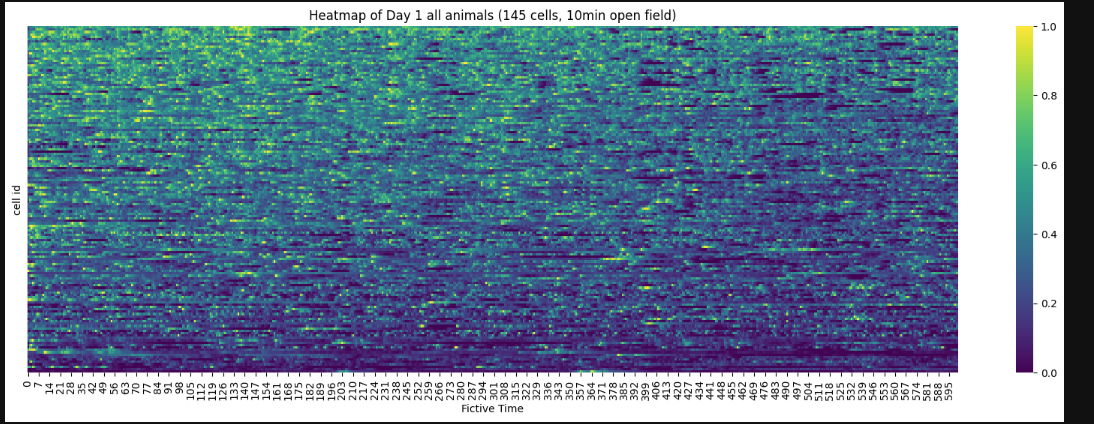